# 05 - Unsupervised Customer Complaint Categorization
## Customer Feedback Intelligence System

### Objectives:
- Isolate negative feedback (Ratings 1 & 2) representing actionable complaints.
- Apply Elbow Method and Silhouette Analysis to identify the optimal cluster count $K$.
- Fit K-Means Clustering on complaint review vectors.
- Extract cluster centroid keywords to assign descriptive business labels.
- Persist the trained clustering model for real-time root-cause analysis.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

DATA_PATH = Path("../data/processed/cleaned_reviews.csv")
MODELS_DIR = Path("../models")
FIGURES_PATH = Path("../reports/figures")

df = pd.read_csv(DATA_PATH)

# Filter complaints strictly (Ratings <= 2)
complaints_df = df[df["Rating"] <= 2].copy()
print(f"Total Negative Complaint Reviews: {len(complaints_df)}")

Total Negative Complaint Reviews: 2369


In [2]:
# 1. Feature Representation for Complaints
# Using focused unigrams/bigrams for root-cause issues
complaint_vectorizer = TfidfVectorizer(
    max_features=2500,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X_comp = complaint_vectorizer.fit_transform(complaints_df["Review Text"].astype(str))
print("Complaints TF-IDF Matrix Shape:", X_comp.shape)

Complaints TF-IDF Matrix Shape: (2369, 2500)


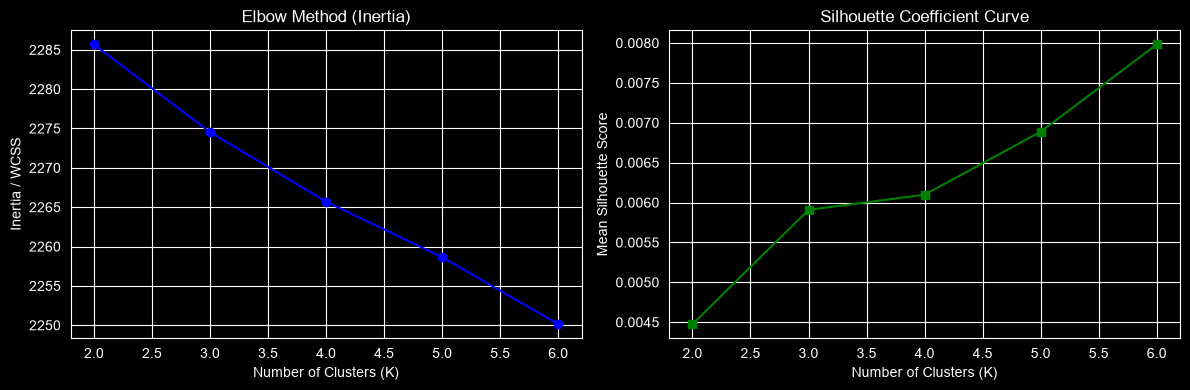

In [3]:
# 2. Determine Optimal K (Elbow Method & Silhouette Scores)
k_values = range(2, 7)
inertia_scores = []
silhouette_vals = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_comp)
    inertia_scores.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_comp, labels, sample_size=1500, random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_values, inertia_scores, marker='o', color='b')
ax1.set_title("Elbow Method (Inertia)")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia / WCSS")

ax2.plot(k_values, silhouette_vals, marker='s', color='g')
ax2.set_title("Silhouette Coefficient Curve")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Mean Silhouette Score")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "kmeans_elbow_silhouette.png")
plt.show()

In [4]:
# 3. Fit K-Means Model with Selected Optimal K (K=4)
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
complaints_df["Cluster"] = kmeans_model.fit_predict(X_comp)

# 4. Extract Top Term Centroids for Each Cluster
order_centroids = kmeans_model.cluster_centers_.argsort()[:, ::-1]
terms = complaint_vectorizer.get_feature_names_out()

cluster_definitions = {}
for i in range(optimal_k):
    top_terms = [terms[ind] for ind in order_centroids[i, :8]]
    cluster_definitions[i] = top_terms
    print(f"Cluster {i}: {', '.join(top_terms)}")

Cluster 0: dress, like, fabric, just, really, fit, look, love
Cluster 1: like, fabric, sweater, just, quality, looks, look, material
Cluster 2: size, small, ordered, fit, large, like, medium, wear
Cluster 3: shirt, like, fabric, short, love, look, boxy, fit


In [5]:
# 5. Map Cluster Centroid Keywords to Business Actionable Labels
# Example Business Mapping based on extracted terms:
business_labels = {
    0: "Fit & Sizing Discrepancies",
    1: "Material, Fabric & Sheerness Quality",
    2: "Cut, Design & Zipper Defects",
    3: "Order Fulfillment, Return & Customer Support"
}

complaints_df["Category_Name"] = complaints_df["Cluster"].map(business_labels)
print("\nComplaint Distribution by Identified Root-Cause Category:")
print(complaints_df["Category_Name"].value_counts())


Complaint Distribution by Identified Root-Cause Category:
Category_Name
Material, Fabric & Sheerness Quality            1173
Cut, Design & Zipper Defects                     505
Fit & Sizing Discrepancies                       482
Order Fulfillment, Return & Customer Support     209
Name: count, dtype: int64


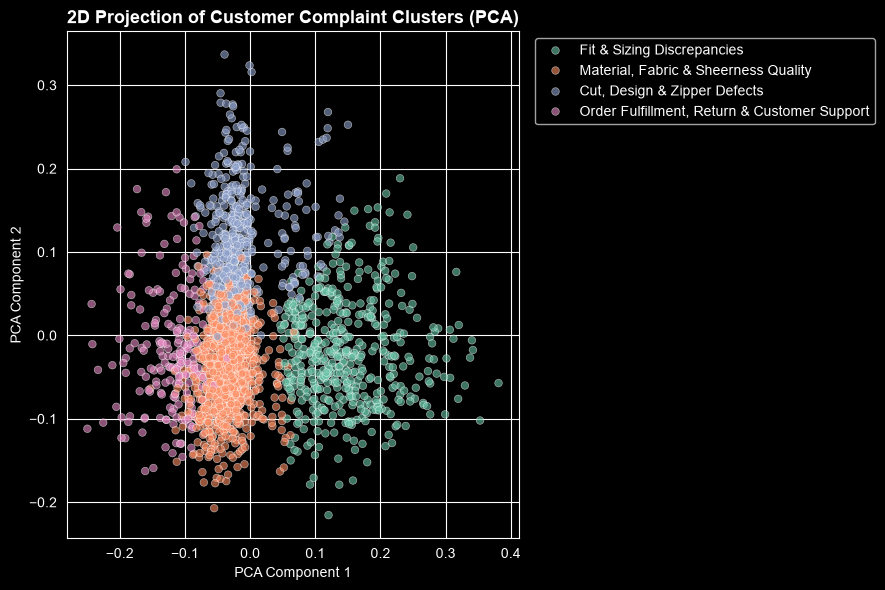

Saved clustering model to models/kmeans_complaints_model.pkl


In [6]:
# 6. Visualize Clusters in 2D Space using PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_comp.toarray())

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=coords[:, 0], y=coords[:, 1],
    hue=complaints_df["Category_Name"],
    palette="Set2",
    alpha=0.6,
    s=30
)
plt.title("2D Projection of Customer Complaint Clusters (PCA)", fontsize=13, fontweight="bold")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_PATH / "complaint_clusters_pca.png")
plt.show()

# 7. Persist K-Means Clustering Model
joblib.dump(kmeans_model, MODELS_DIR / "kmeans_complaints_model.pkl")
print("Saved clustering model to models/kmeans_complaints_model.pkl")